In [1]:
"""
PS5E9 Competition - Exploratory Data Analysis (Kaggle Version)
Comprehensive EDA for BPM Prediction using TabML's visualization tools
"""

import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from loguru import logger
import warnings
warnings.filterwarnings('ignore')

# Install tabml if not already installed (for Kaggle)
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install required packages for Kaggle
try:
    from tabml import EDAAnalyzer
except ImportError:
    print("Installing tabml and dependencies...")
    install_package("git+https://github.com/wguesdon/tabml.git")
    install_package("loguru")
    from tabml import EDAAnalyzer

# Setup paths for Kaggle
DATA_DIR = Path("/kaggle/input/playground-series-s5e9/")
OUTPUT_DIR = Path("/kaggle/working/output/eda_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Competition settings
TARGET_COL = 'BeatsPerMinute'


def perform_eda():
    """Perform comprehensive EDA on PS5E9 BPM prediction data."""
    logger.info("="*60)
    logger.info("PS5E9 COMPETITION - BPM PREDICTION EDA")
    logger.info("="*60)
    
    # Load data
    logger.info("\nLoading competition data...")
    train_df = pd.read_csv(DATA_DIR / "train.csv")
    test_df = pd.read_csv(DATA_DIR / "test.csv")
    
    logger.info(f"Train shape: {train_df.shape}")
    logger.info(f"Test shape: {test_df.shape}")
    
    # Drop ID column for analysis
    train_df_analysis = train_df.drop('id', axis=1)
    test_df_analysis = test_df.drop('id', axis=1)
    
    # Initialize EDA Analyzer with viridis palette for continuous data
    logger.info("\nInitializing EDA Analyzer...")
    eda = EDAAnalyzer(figsize=(14, 8), style='seaborn-v0_8-darkgrid', palette='viridis', n_cols=3)
    
    # 1. Generate complete EDA report for training data
    logger.info("\n" + "="*40)
    logger.info("COMPREHENSIVE EDA REPORT - TRAINING DATA")
    logger.info("="*40)
    
    eda.generate_report(
        train_df_analysis,
        target=TARGET_COL,
        output_dir=str(OUTPUT_DIR / "train"),
        max_categories=20
    )
    
    # 2. Target (BPM) distribution analysis
    logger.info("\n" + "="*40)
    logger.info("TARGET (BPM) DISTRIBUTION ANALYSIS")
    logger.info("="*40)
    
    target_stats = train_df_analysis[TARGET_COL].describe()
    logger.info(f"\nBPM statistics:\n{target_stats}")
    
    # Check for outliers in BPM
    Q1 = train_df_analysis[TARGET_COL].quantile(0.25)
    Q3 = train_df_analysis[TARGET_COL].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_df_analysis[(train_df_analysis[TARGET_COL] < lower_bound) | 
                                 (train_df_analysis[TARGET_COL] > upper_bound)]
    
    logger.info(f"\nBPM Outliers (using IQR method):")
    logger.info(f"  Lower bound: {lower_bound:.2f}")
    logger.info(f"  Upper bound: {upper_bound:.2f}")
    logger.info(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(train_df_analysis)*100:.2f}%)")
    
    # BPM ranges (music domain knowledge)
    logger.info("\nBPM Distribution by Music Tempo Categories:")
    bpm_ranges = {
        'Very Slow (< 60)': (0, 60),
        'Slow (60-90)': (60, 90),
        'Moderate (90-120)': (90, 120),
        'Fast (120-150)': (120, 150),
        'Very Fast (150-180)': (150, 180),
        'Extreme (> 180)': (180, float('inf'))
    }
    
    for category, (low, high) in bpm_ranges.items():
        if high == float('inf'):
            count = len(train_df_analysis[train_df_analysis[TARGET_COL] >= low])
        else:
            count = len(train_df_analysis[(train_df_analysis[TARGET_COL] >= low) & 
                                         (train_df_analysis[TARGET_COL] < high)])
        pct = count / len(train_df_analysis) * 100
        logger.info(f"  {category}: {count:,} samples ({pct:.1f}%)")
    
    # 3. Feature analysis
    logger.info("\n" + "="*40)
    logger.info("FEATURE ANALYSIS")
    logger.info("="*40)
    
    feature_cols = [col for col in train_df_analysis.columns if col != TARGET_COL]
    
    logger.info(f"\nAnalyzing {len(feature_cols)} audio features:")
    for col in feature_cols:
        col_stats = train_df_analysis[col].describe()
        logger.info(f"\n{col}:")
        logger.info(f"  Mean: {col_stats['mean']:.4f}")
        logger.info(f"  Std: {col_stats['std']:.4f}")
        logger.info(f"  Range: [{col_stats['min']:.4f}, {col_stats['max']:.4f}]")
        logger.info(f"  Skewness: {train_df_analysis[col].skew():.4f}")
    
    # 4. Univariate analysis of features
    logger.info("\n" + "="*40)
    logger.info("UNIVARIATE ANALYSIS")
    logger.info("="*40)
    
    logger.info(f"\nCreating distribution plots for all features...")
    univariate_dir = OUTPUT_DIR / "univariate"
    eda.plot_univariate(
        train_df_analysis,
        save_dir=str(univariate_dir),
        individual_plots=True
    )
    
    # 5. Multivariate analysis - Features vs BPM
    logger.info("\n" + "="*40)
    logger.info("MULTIVARIATE ANALYSIS - FEATURES VS BPM")
    logger.info("="*40)
    
    multivariate_dir = OUTPUT_DIR / "multivariate"
    eda.plot_multivariate(
        train_df_analysis,
        target=TARGET_COL,
        features=feature_cols,
        save_dir=str(multivariate_dir),
        individual_plots=True
    )
    
    # 6. Correlation analysis
    logger.info("\n" + "="*40)
    logger.info("CORRELATION ANALYSIS")
    logger.info("="*40)
    
    # Pearson correlation
    eda.plot_correlation_matrix(
        train_df_analysis,
        method='pearson',
        save_path=str(OUTPUT_DIR / "correlation_pearson.png")
    )
    
    # Spearman correlation for non-linear relationships
    eda.plot_correlation_matrix(
        train_df_analysis,
        method='spearman',
        save_path=str(OUTPUT_DIR / "correlation_spearman.png")
    )
    
    # Feature correlations with BPM
    correlations = train_df_analysis.corr()[TARGET_COL].abs().sort_values(ascending=False)
    
    logger.info("\nFeature correlations with BPM (absolute values):")
    for feat, corr in correlations[1:].items():  # Skip target itself
        logger.info(f"  {feat}: {corr:.4f}")
    
    # 7. Missing data analysis
    logger.info("\n" + "="*40)
    logger.info("MISSING DATA ANALYSIS")
    logger.info("="*40)
    
    eda.plot_missing_data(
        train_df_analysis,
        save_path=str(OUTPUT_DIR / "missing_data.png")
    )
    
    missing_counts = train_df_analysis.isnull().sum()
    if missing_counts.sum() > 0:
        logger.info("\nColumns with missing values:")
        for col, count in missing_counts[missing_counts > 0].items():
            pct = count / len(train_df_analysis) * 100
            logger.info(f"  {col}: {count} ({pct:.2f}%)")
    else:
        logger.info("No missing values found in the dataset!")
    
    # 8. Feature relationships and patterns
    logger.info("\n" + "="*40)
    logger.info("FEATURE RELATIONSHIPS AND PATTERNS")
    logger.info("="*40)
    
    # Energy vs Rhythm relationship with BPM
    if 'Energy' in feature_cols and 'RhythmScore' in feature_cols:
        # Create interaction feature
        energy_rhythm = train_df_analysis['Energy'] * train_df_analysis['RhythmScore']
        energy_rhythm_corr = energy_rhythm.corr(train_df_analysis[TARGET_COL])
        
        logger.info("\nInteraction Features:")
        logger.info(f"  Energy * RhythmScore correlation with BPM: {energy_rhythm_corr:.4f}")
        logger.info(f"  vs Energy alone: {train_df_analysis['Energy'].corr(train_df_analysis[TARGET_COL]):.4f}")
        logger.info(f"  vs RhythmScore alone: {train_df_analysis['RhythmScore'].corr(train_df_analysis[TARGET_COL]):.4f}")
    
    # Duration normalized features
    if 'TrackDurationMs' in feature_cols:
        logger.info("\nDuration-based insights:")
        duration_minutes = train_df_analysis['TrackDurationMs'] / 60000
        logger.info(f"  Average track duration: {duration_minutes.mean():.2f} minutes")
        logger.info(f"  Duration range: {duration_minutes.min():.2f} - {duration_minutes.max():.2f} minutes")
        
        # Check if longer tracks have different BPM patterns
        long_tracks = train_df_analysis[duration_minutes > duration_minutes.quantile(0.75)]
        short_tracks = train_df_analysis[duration_minutes < duration_minutes.quantile(0.25)]
        logger.info(f"  Long tracks (>75th percentile) avg BPM: {long_tracks[TARGET_COL].mean():.2f}")
        logger.info(f"  Short tracks (<25th percentile) avg BPM: {short_tracks[TARGET_COL].mean():.2f}")
    
    # 9. Adversarial Validation
    logger.info("\n" + "="*40)
    logger.info("ADVERSARIAL VALIDATION")
    logger.info("="*40)
    
    try:
        adv_results = eda.adversarial_validation(
            train_df=train_df,
            test_df=test_df,
            target_col=TARGET_COL,
            n_folds=5,
            sample_size=50000,
            save_path=str(OUTPUT_DIR / "adversarial_validation.png")
        )
        
        logger.info(f"\nAdversarial Validation Results:")
        logger.info(f"  AUC Score: {adv_results['auc_score']:.4f}")
        logger.info(f"  Interpretation: {adv_results['interpretation']}")
        
        if adv_results['feature_importance'] is not None and not adv_results['feature_importance'].empty:
            logger.info("\nFeatures causing distribution shift:")
            for _, row in adv_results['feature_importance'].head(5).iterrows():
                logger.info(f"  - {row['feature']}: {row['importance']:.4f}")
    except Exception as e:
        logger.warning(f"Adversarial validation failed: {e}")
        logger.info("Skipping adversarial validation...")
    
    # 10. Train vs Test distribution comparison
    logger.info("\n" + "="*40)
    logger.info("TRAIN VS TEST DISTRIBUTION COMPARISON")
    logger.info("="*40)
    
    logger.info(f"\nComparing {len(feature_cols)} features between train and test...")
    
    distribution_diffs = {}
    for col in feature_cols:
        train_mean = train_df_analysis[col].mean()
        test_mean = test_df_analysis[col].mean()
        train_std = train_df_analysis[col].std()
        test_std = test_df_analysis[col].std()
        
        mean_diff = abs(train_mean - test_mean) / (abs(train_mean) + 1e-10)
        std_diff = abs(train_std - test_std) / (abs(train_std) + 1e-10)
        
        distribution_diffs[col] = {
            'mean_diff_%': mean_diff * 100,
            'std_diff_%': std_diff * 100
        }
    
    # Report significant differences
    significant_diffs = []
    for col, diffs in distribution_diffs.items():
        if diffs['mean_diff_%'] > 10 or diffs['std_diff_%'] > 10:
            significant_diffs.append(col)
            logger.warning(f"  {col}: Mean diff={diffs['mean_diff_%']:.1f}%, Std diff={diffs['std_diff_%']:.1f}%")
        else:
            logger.info(f"  {col}: Mean diff={diffs['mean_diff_%']:.1f}%, Std diff={diffs['std_diff_%']:.1f}%")
    
    if significant_diffs:
        logger.warning(f"\n⚠️ {len(significant_diffs)} features show significant distribution differences")
    
    # 11. Feature engineering recommendations
    logger.info("\n" + "="*40)
    logger.info("FEATURE ENGINEERING RECOMMENDATIONS")
    logger.info("="*40)
    
    logger.info("\n📊 Based on EDA, consider these feature engineering approaches:")
    
    logger.info("\n1. Domain-specific features:")
    logger.info("   - Tempo categories (slow/medium/fast)")
    logger.info("   - Energy per minute (Energy / Duration)")
    logger.info("   - Rhythm-Energy interaction")
    logger.info("   - Acoustic vs Electronic indicator")
    
    logger.info("\n2. Statistical transformations:")
    logger.info("   - Log transform for skewed features (e.g., TrackDurationMs)")
    logger.info("   - Polynomial features for top correlated variables")
    logger.info("   - Standardization for tree-based models")
    
    logger.info("\n3. Interaction features:")
    logger.info("   - Energy × RhythmScore")
    logger.info("   - VocalContent × AcousticQuality")
    logger.info("   - MoodScore × Energy")
    
    # 12. Summary
    logger.info("\n" + "="*60)
    logger.info("EDA SUMMARY")
    logger.info("="*60)
    
    logger.info("\n📈 Key Findings:")
    logger.info(f"  • Dataset: {len(train_df_analysis):,} training, {len(test_df_analysis):,} test samples")
    logger.info(f"  • Features: {len(feature_cols)} audio/music features")
    logger.info(f"  • Target: BPM (continuous, range: {train_df_analysis[TARGET_COL].min():.1f}-{train_df_analysis[TARGET_COL].max():.1f})")
    logger.info(f"  • Missing data: {'None' if missing_counts.sum() == 0 else f'{missing_counts.sum()} columns'}")
    logger.info(f"  • Outliers: {len(outliers)} BPM outliers ({len(outliers)/len(train_df_analysis)*100:.2f}%)")
    
    # Find strongest predictors
    top_predictors = correlations[1:4].index.tolist()
    logger.info(f"  • Top predictors: {', '.join(top_predictors)}")
    
    logger.info("\n🎯 Modeling Strategy:")
    logger.info("  1. Use ensemble of gradient boosting models (XGBoost, LightGBM, CatBoost)")
    logger.info("  2. Consider neural networks for capturing complex patterns")
    logger.info("  3. Apply feature engineering based on music domain knowledge")
    logger.info("  4. Use RMSE as primary metric, monitor MAE and R²")
    logger.info("  5. Implement robust cross-validation (5-fold or 10-fold)")
    
    logger.info(f"\n✅ All visualizations saved to {OUTPUT_DIR}/")
    logger.info("\nEDA Complete! Ready to proceed with modeling.")
    
    return train_df_analysis, test_df_analysis, feature_cols


# For Jupyter/Kaggle notebook execution
if __name__ == "__main__":
    # Run the EDA
    try:
        train_data, test_data, features = perform_eda()
        print("\n✅ EDA completed successfully!")
        print(f"Training data shape: {train_data.shape}")
        print(f"Test data shape: {test_data.shape}")
        print(f"Number of features: {len(features)}")
    except Exception as e:
        logger.error(f"Error during EDA: {e}")
        raise

2025-09-01 16:21:42.196 | INFO     | tabml._init_helpers:setup_nltk_data:21 - Downloading NLTK averaged_perceptron_tagger...
2025-09-01 16:21:48.400 | INFO     | tabml._init_helpers:initialize_tabml:113 - TabML initialized successfully
2025-09-01 16:21:48.401 | INFO     | tabml._init_helpers:initialize_tabml:116 - TabNet not available. Install with: pip install pytorch-tabnet
2025-09-01 16:21:56.399 | WARNING  | tabml.models:<module>:59 - TabNet not installed. Install with: pip install pytorch-tabnet
2025-09-01 16:21:56.697 | WARNING  | tabml.autogluon_model:<module>:49 - AutoGluon not installed. Install with: pip install autogluon
2025-09-01 16:21:56.701 | INFO     | __main__:perform_eda:42 - ============================================================
2025-09-01 16:21:56.702 | INFO     | __main__:perform_eda:43 - PS5E9 COMPETITION - BPM PREDICTION EDA
2025-09-01 16:21:56.702 | INFO     | __main__:perform_eda:44 - ============================================================
2025-09-01


✅ EDA completed successfully!
Training data shape: (524164, 10)
Test data shape: (174722, 9)
Number of features: 9


# EDA Insights

- no missing data

# Adversarial Validation

- The train and test datasets have similar distributions. 

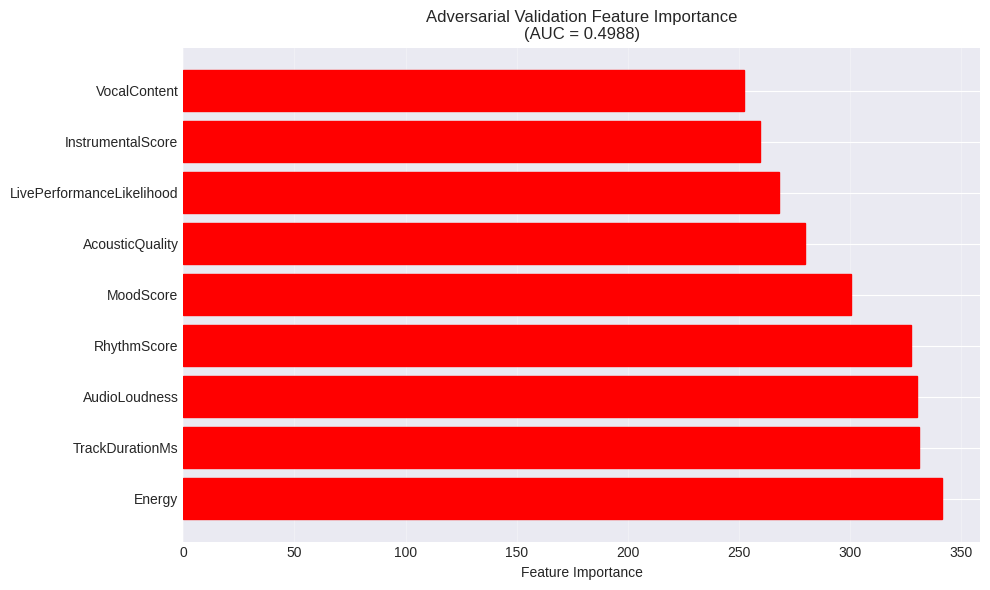

In [2]:
from IPython.display import Image
Image(filename='/kaggle/working/output/eda_analysis/adversarial_validation.png')

# Univariate analysis

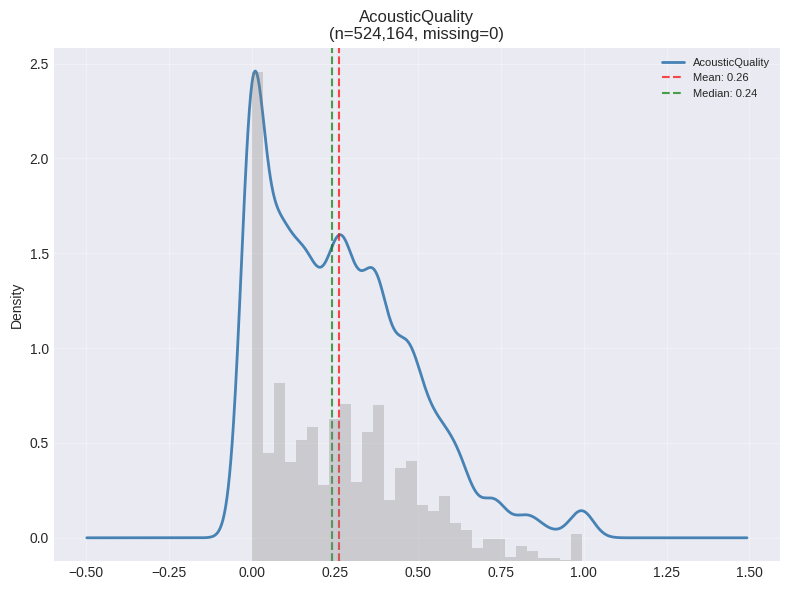

In [3]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/AcousticQuality.png')

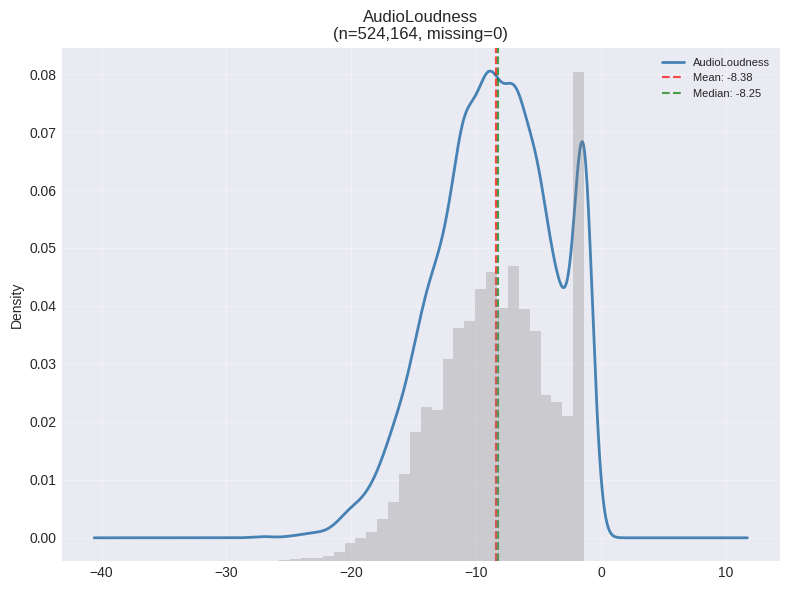

In [4]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/AudioLoudness.png')

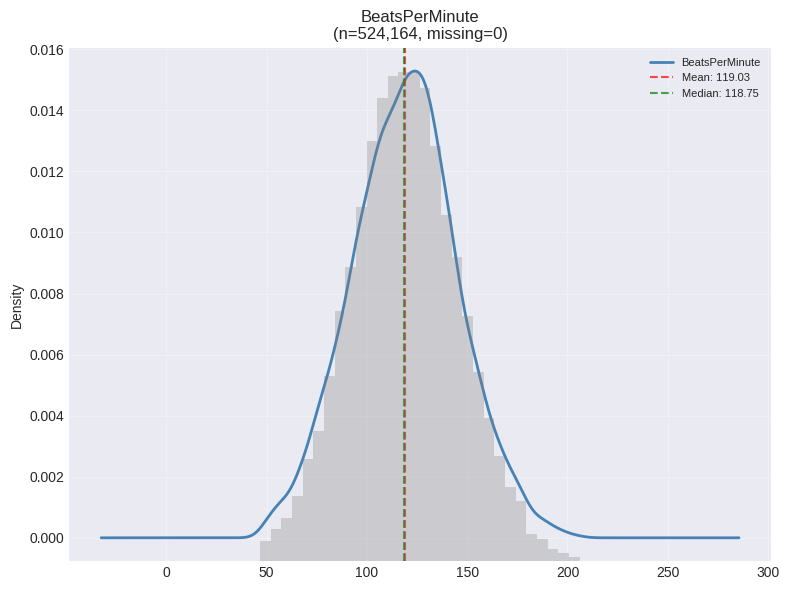

In [5]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/BeatsPerMinute.png')

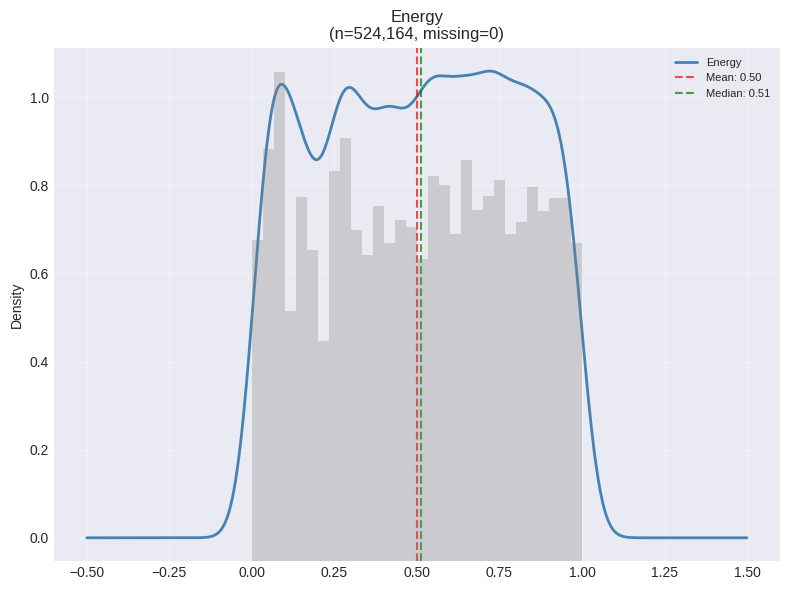

In [6]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/Energy.png')

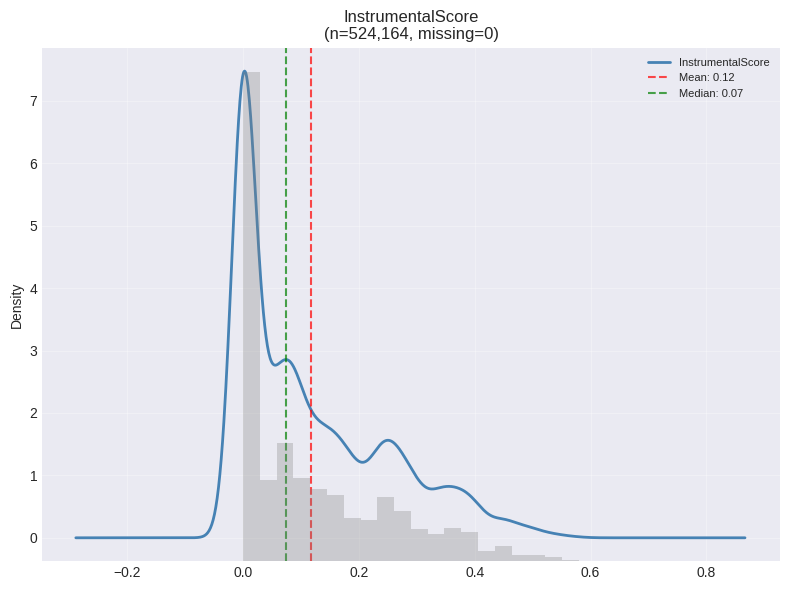

In [7]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/InstrumentalScore.png')

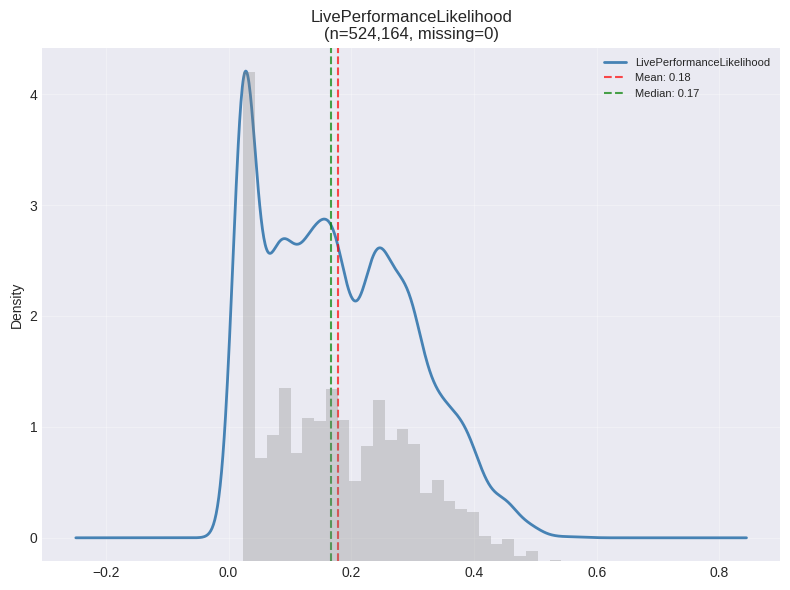

In [8]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/LivePerformanceLikelihood.png')

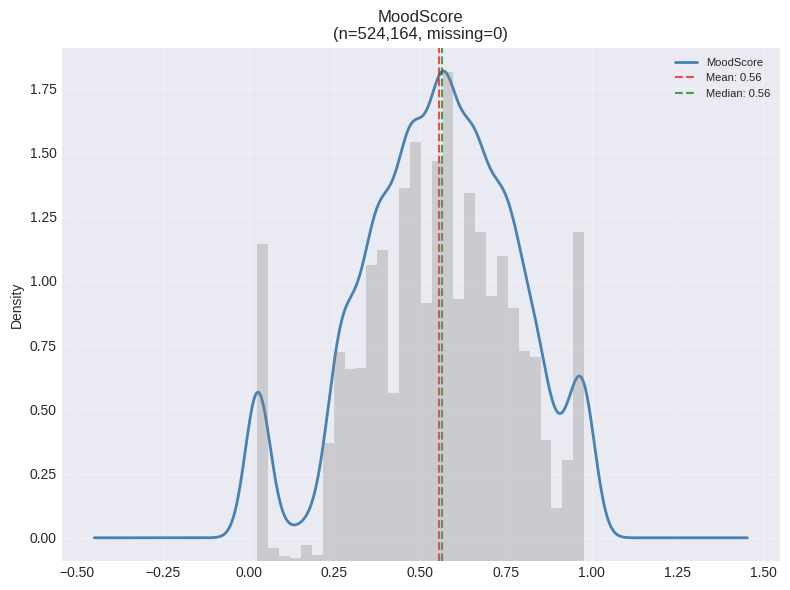

In [9]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/MoodScore.png')

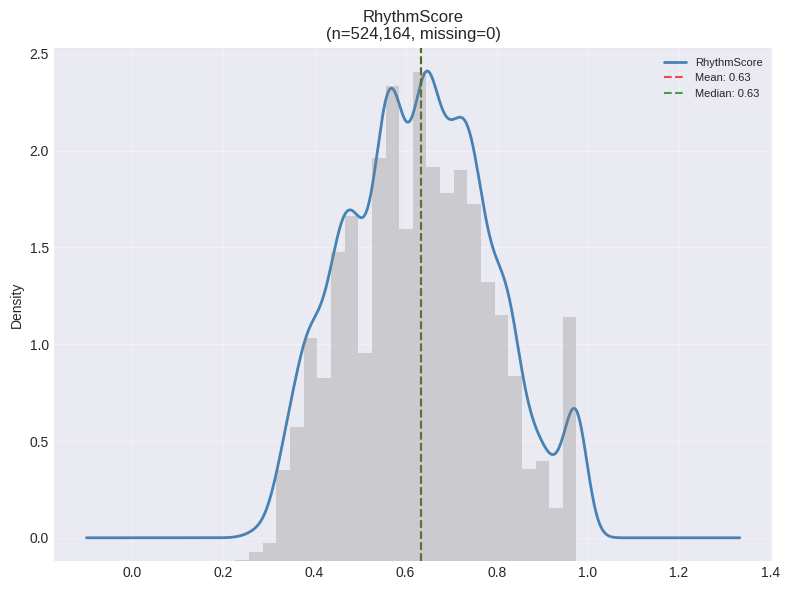

In [10]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/RhythmScore.png')

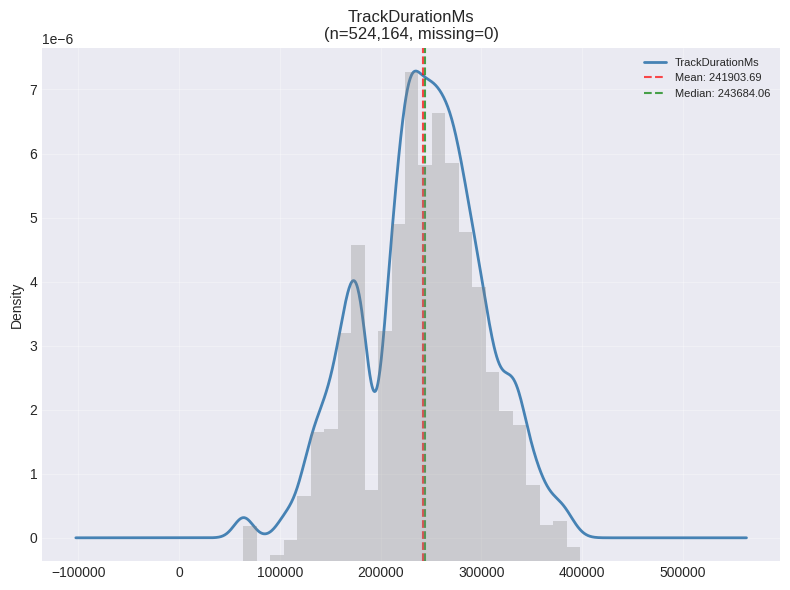

In [11]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/TrackDurationMs.png')

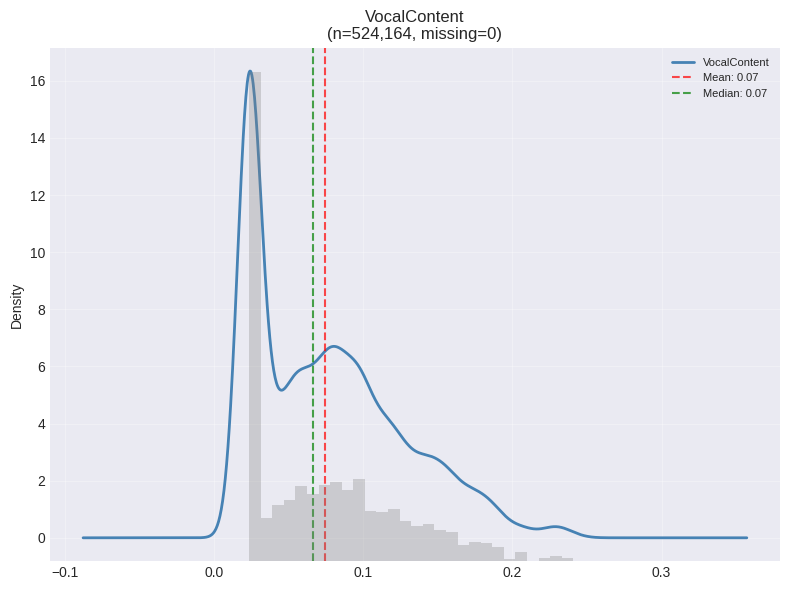

In [12]:
Image(filename='/kaggle/working/output/eda_analysis/univariate/VocalContent.png')

# Multivariate analysis

- No clear patterns between Target and features. Will try again with engineered features.
- The synthetic data generation itself might have generated some signal, as we saw in the Feb 2025 competition. Will try to test and capture this in the EDA.

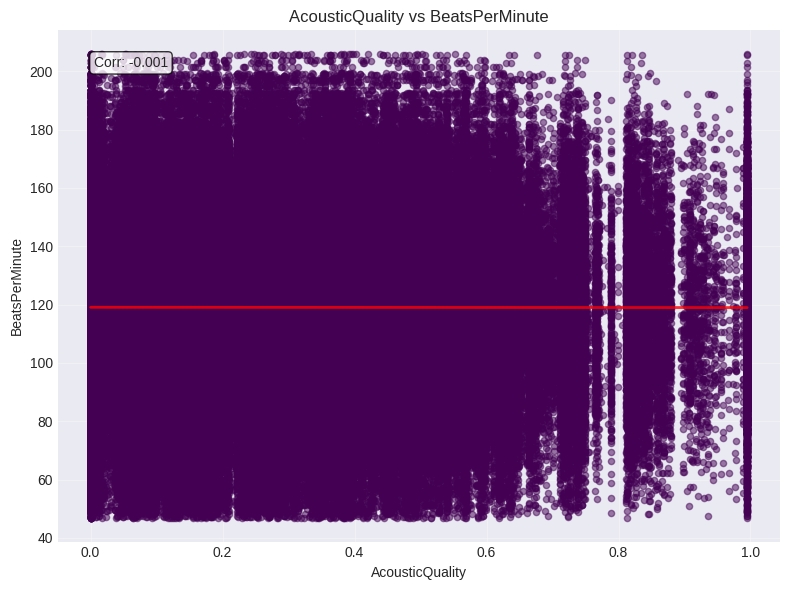

In [13]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/AcousticQuality_vs_BeatsPerMinute.png')

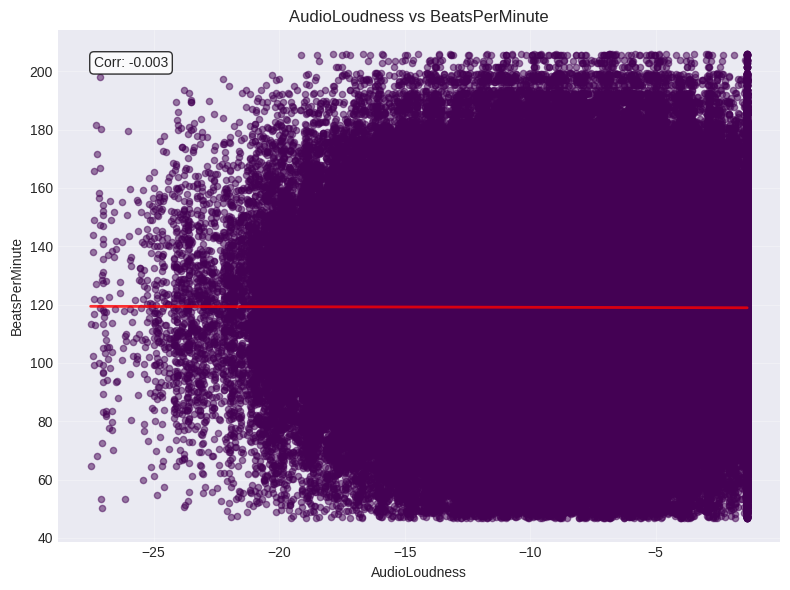

In [14]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/AudioLoudness_vs_BeatsPerMinute.png')

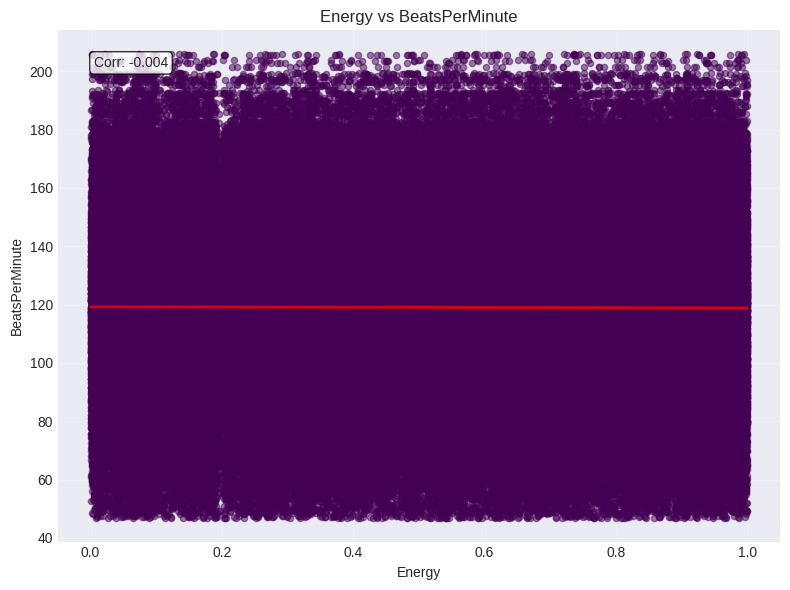

In [15]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/Energy_vs_BeatsPerMinute.png')

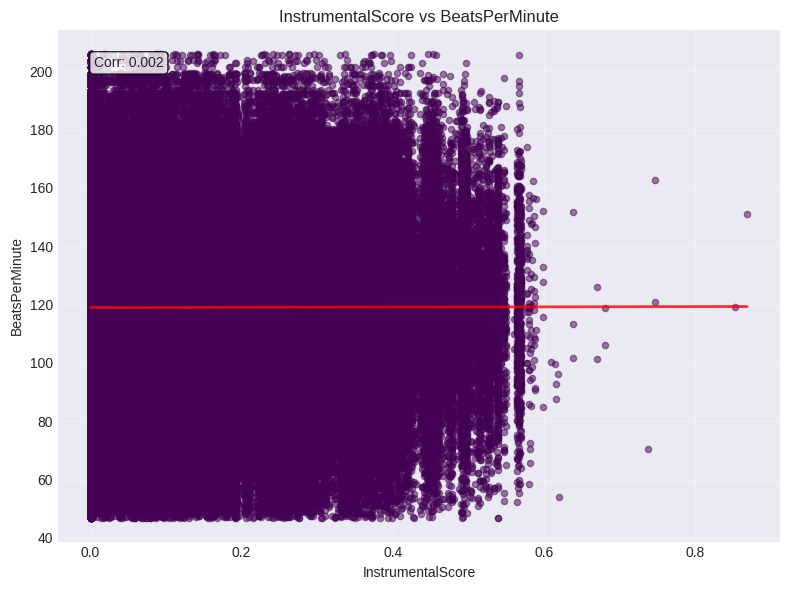

In [16]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/InstrumentalScore_vs_BeatsPerMinute.png')

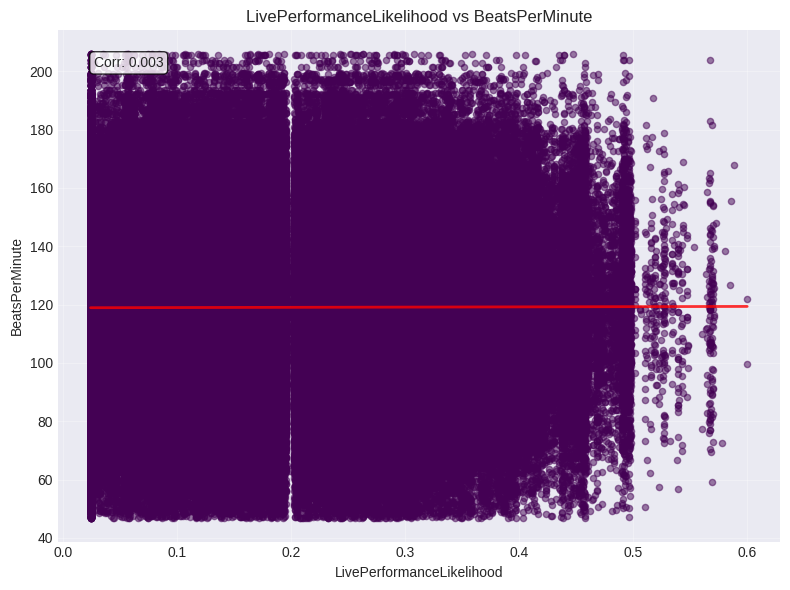

In [17]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/LivePerformanceLikelihood_vs_BeatsPerMinute.png')

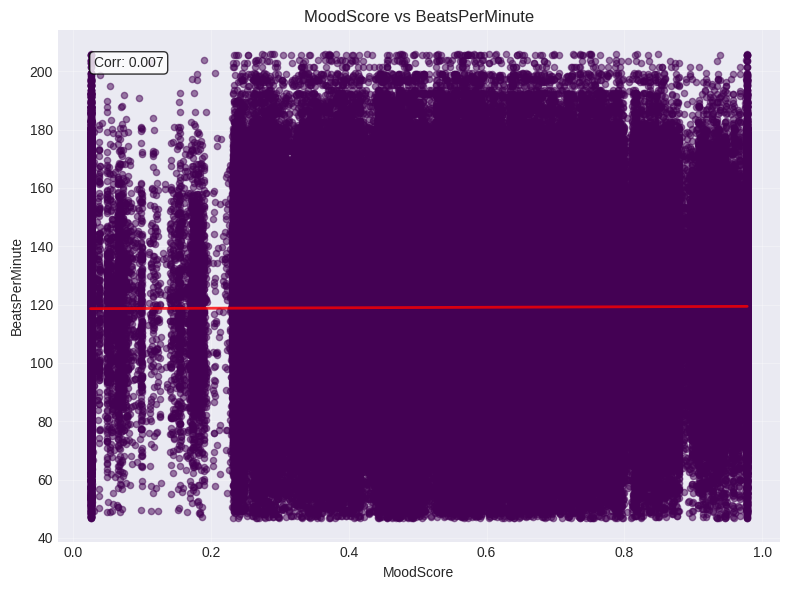

In [18]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/MoodScore_vs_BeatsPerMinute.png')

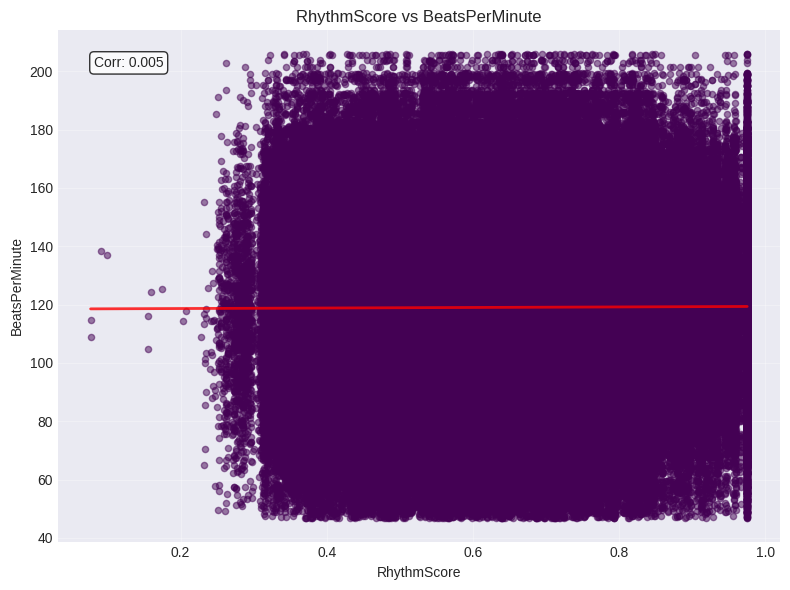

In [19]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/RhythmScore_vs_BeatsPerMinute.png')

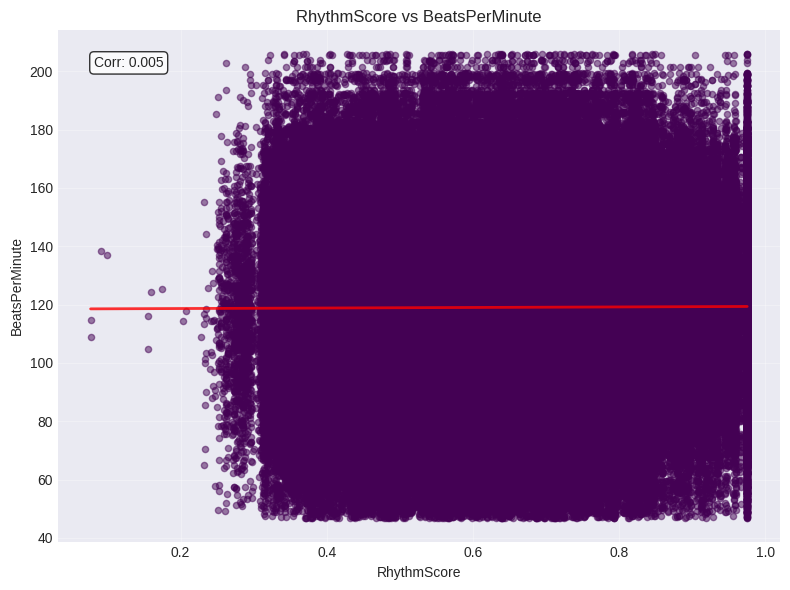

In [20]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/RhythmScore_vs_BeatsPerMinute.png')

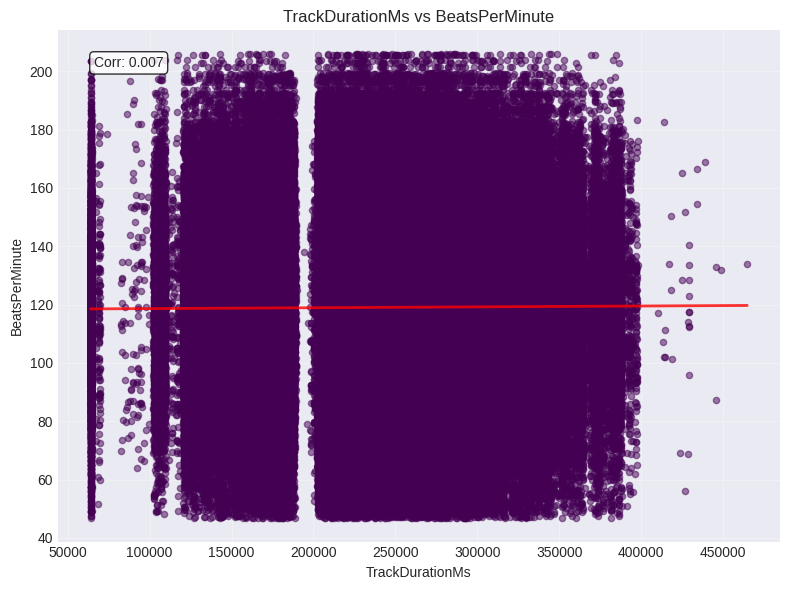

In [21]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/TrackDurationMs_vs_BeatsPerMinute.png')

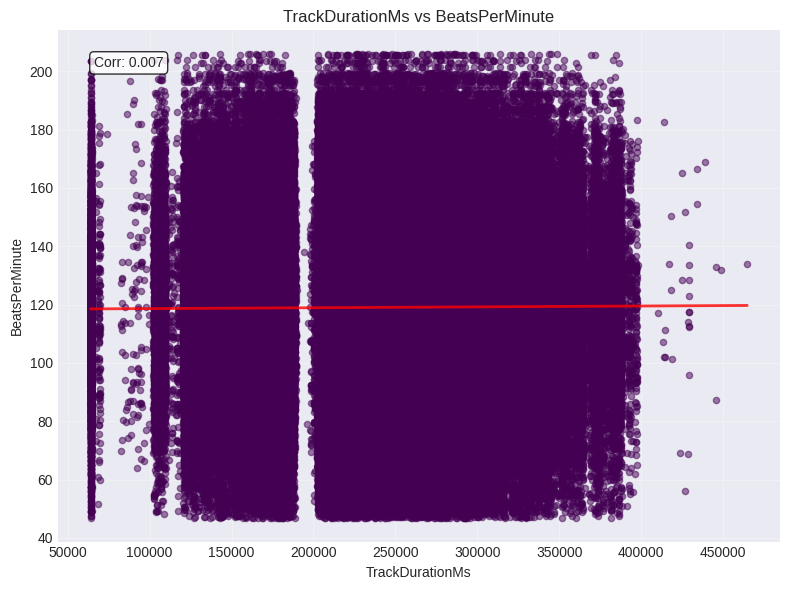

In [22]:
Image(filename='/kaggle/working/output/eda_analysis/train/multivariate/TrackDurationMs_vs_BeatsPerMinute.png')

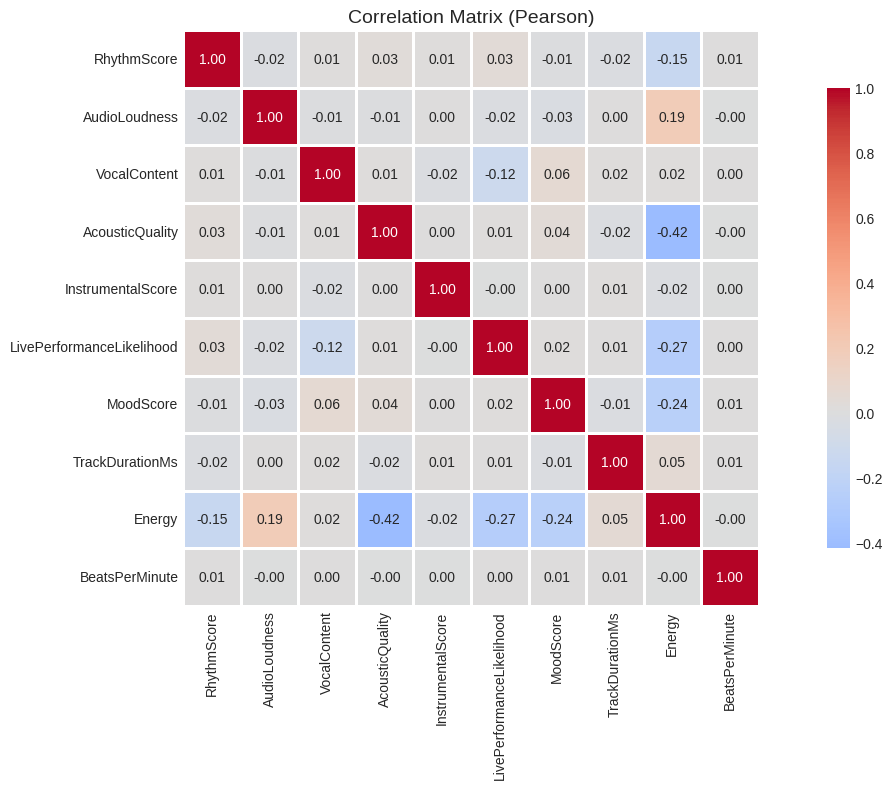

In [23]:
Image(filename='/kaggle/working/output/eda_analysis/train/correlation.png')